# Propensity-Based Audience Optimization

# CHECK SPELLING OF BIG BLOCKS

### Context

The client defined use case for this effort: **use predictive analytics to identify the customers most likely to engage, then target those segments only.**  Goal: to increse the number of customers reached (i.e., opens/clicks) by 25% over six months while keeping total campaign volume constant.


### Data Description

The cleaned dataset includes 3 years of historical campaign data:
- customer_id: unique, anonamized campaign data.
- age, income, tenure: customer demographics
- ;ast_[rucajse_days: days since last purchase
- avg_order_value: average order value
- campaign_channel: email, social, push
- campaign_type: promotional, informational,  loyalty
- sent: whether the customer was sent campaight(0/1)
- opened: whether the customer opened the email (target variable)
- converted: whether the customet made a purchase (secondary)

Using historical data (synthetically generated for the public facing notebook) preditions are made on the opened feature. Then all customers are scored and the top 30% are considered the most likely to engage. The most likely customers will then be compared to the expected reach (number of opens, this was also synthetically generated) versus sending it to everyone. 

In [1]:
# library imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

## Generate Synthetic Data, and Target Variable

In [2]:
# Random see for reprocuibility
np.random.seed(42)

# Generating synthetic customer data
n_customers = 5000
data = {
    'customer_id': range(1, n_customers+1),
    'age' : np.random.randint(18, 70, n_customers),
    'income': np.random.normal(50000, 15000, n_customers).astype(int), #estimated
    'tenure': np.random.randint(1, 120, n_customers), #months
    'last_purchase_days': np.random.randint(1, 365, n_customers),
    'avg_order_value': np.random.normal(100, 30, n_customers).clip(20, 300).astype(int),
    'campaign_channel': np.random.choice(['email','social', 'push'], n_customers),
    'campaign_type': np.random.choice(['promotional', 'informational', 'loyalty'], n_customers),
    'sent': np.random.choice([0,1], n_customers, p=[0.2,0.8]), #80% were sent
}

df = pd.DataFrame(data)

In [3]:
# Generat target variable 'openeds' baseon on some hidden pattern
# Higher probability if: recent purchases, higher income, email channel, promotional type
def generate_opened(row):
    base_prob = 0.1
    if row['last_purchase_days'] > 60:
        base_prob += 2.0
    if row['income'] > 60000:
        base_prob += 1.0
    if row['campaign_channel'] == 'email':
        base_prob += 0.15
    if row['campaign_type'] == 'promotional':
        base_prob += 0.1
    # cap probability
    prob = min(base_prob, 0.9)
    return np.random.binomial(1, prob)

df['opened'] = df.apply(generate_opened, axis =1)

print("Data shape:", df.shape)
df.head()

Data shape: (5000, 10)


,customer_id,age,income,tenure,last_purchase_days,avg_order_value,campaign_channel,campaign_type,sent,opened
0,1,56,48353,96,249,95,email,loyalty,0,1
1,2,69,57462,92,74,146,push,promotional,1,1
2,3,46,44219,48,319,130,email,loyalty,1,1
3,4,32,56306,39,296,73,social,loyalty,1,1
4,5,60,37034,40,274,82,push,promotional,1,1


## EDA

Opened rate: 81.46%


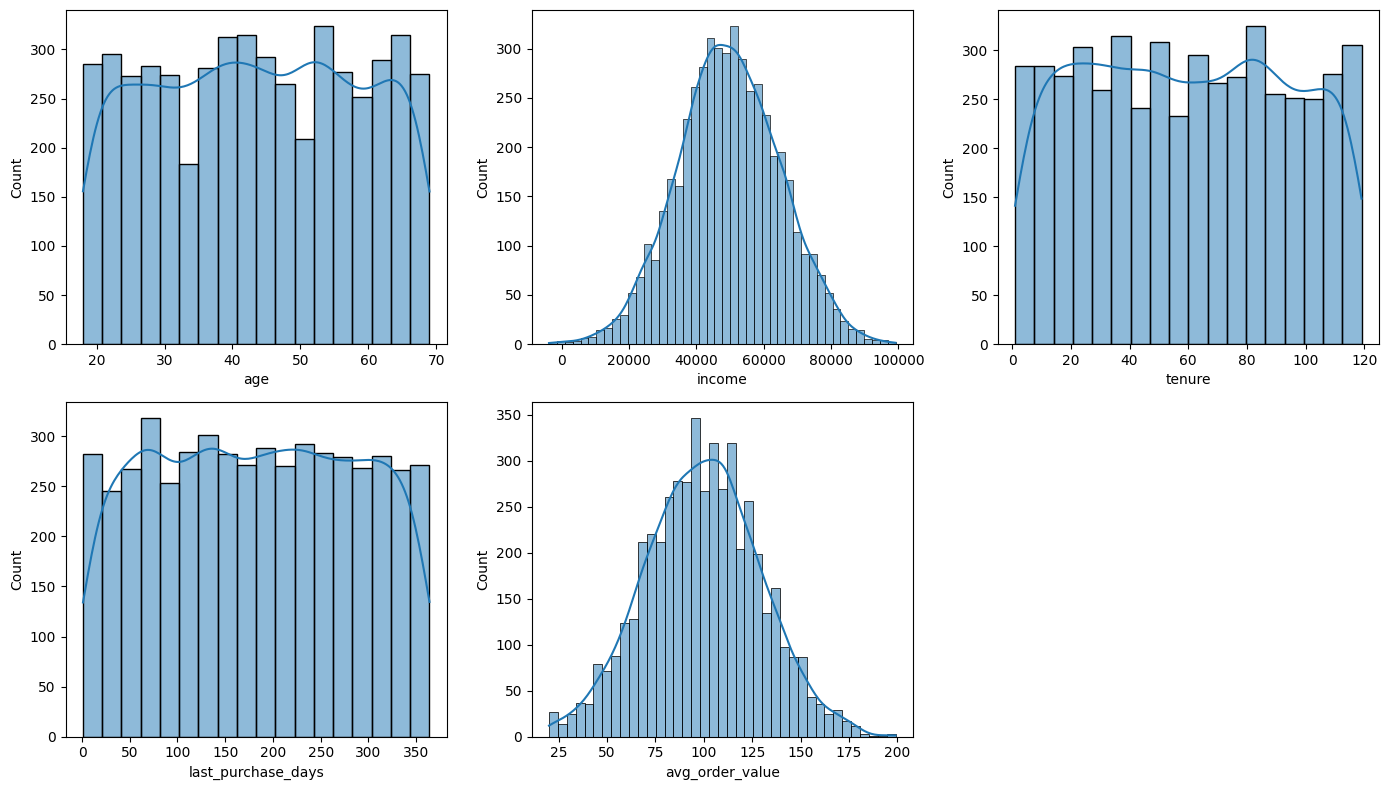

In [4]:
# Check class balance 
    #This helps make sure the 
print("Opened rate: {:.2f}%".format(df['opened'].mean()*100))

# Distribution of features
#  Histograms with KDE: shows distribution of slect features, overlayed with smoothed density curve.
fig, axes = plt.subplots(2,3, figsize=(14,8))
sns.histplot(df['age'], kde=True, ax=axes[0,0]) 
sns.histplot(df['income'], kde=True, ax=axes[0,1])
sns.histplot(df['tenure'], kde=True, ax=axes[0,2])
sns.histplot(df['last_purchase_days'], kde=True, ax=axes[1,0])
sns.histplot(df['avg_order_value'], kde=True, ax=axes[1,1])
axes[1,2].axis('off')
plt.tight_layout()
fig.savefig('Histograms of feature distributions.png')
plt.show()

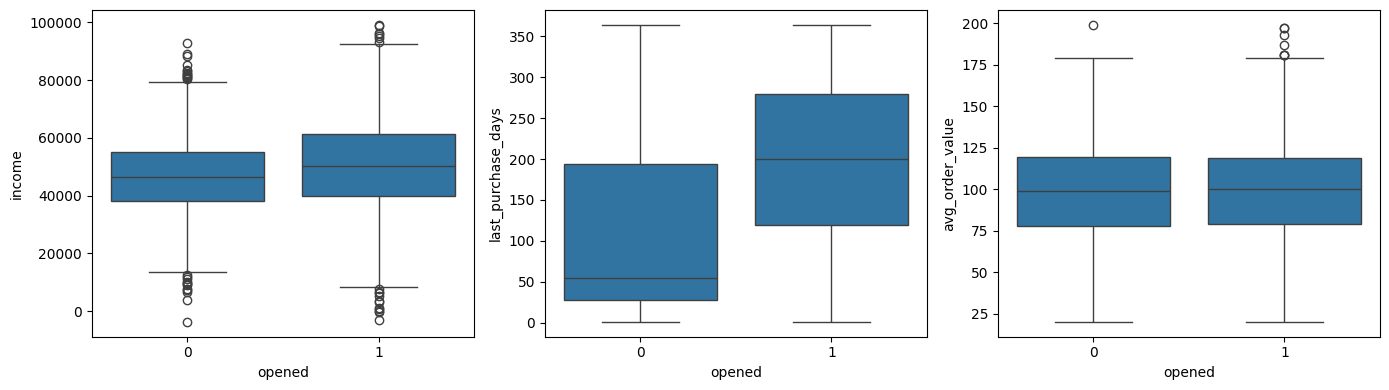

In [5]:
# Relationship with opened
# Boxplot: compares one feature at a time with who opened and who did not, to help us infere impact of feature.
fig, axes = plt.subplots(1,3, figsize=(14,4))
sns.boxplot(x='opened', y='income', data=df, ax=axes[0])
sns.boxplot(x='opened', y='last_purchase_days', data=df, ax=axes[1])
sns.boxplot(x='opened', y='avg_order_value', data=df, ax=axes[2])
plt.tight_layout()
fig.savefig('Feature relationship to being opened.png')
plt.show()

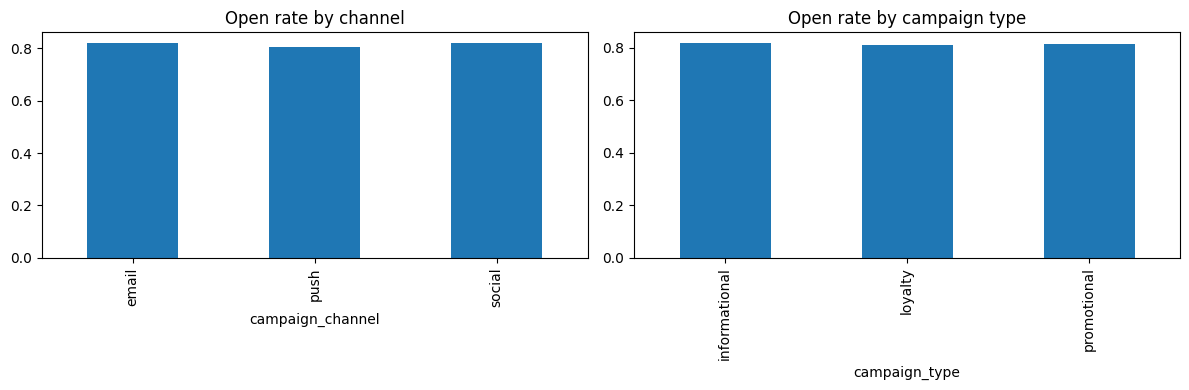

In [6]:
# Categorical features vs opened
#  BAr plot: average open rate per campaign channel
fig, axes = plt.subplots(1,2, figsize=(12,4))
df.groupby('campaign_channel')['opened'].mean().plot(kind='bar', ax=axes[0])
axes[0].set_title('Open rate by channel')
df.groupby('campaign_type')['opened'].mean().plot(kind='bar', ax=axes[1])
axes[1].set_title('Open rate by campaign type')
plt.tight_layout()
fig.savefig('Categorial features vs opened.png')
plt.show()

## 3. Feature Engineering and Preprocessing

In [7]:
# Using only customers who were sent the campaign
train_df = df[df['sent']==1].copy()

# Features for the model
features = ['age', 'income', 'tenure', 'last_purchase_days', 'avg_order_value', 'campaign_channel', 'campaign_type']
X = train_df[features]
y = train_df['opened']

#  Spliting into train and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Preprocessing: scale numeric, one-hot encode categorical
numeric_features = ['age', 'income', 'tenure', 'last_purchase_days', 'avg_order_value']
numeric_transformer = StandardScaler()
categorical_features = ['campaign_channel', 'campaign_type']
categorical_transformer = OneHotEncoder(drop='first', handle_unknown = 'ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

## 4. Building and Training the Random Forest Classifier

This model was chosen for the following reasons:
- Robustness. It handles both categorical and numerical features well. It is resistent to overfitting due to ensemble averaging.
- Interpretability: Provides feature importance providing insight into what factors drive engagement.
- Non-linearity: Captures complex interactions between features without extensive feature engineering.
- Performance: Performs well out of the box on tabular data, good for baseline campign response modeling. We didnt dive too deep into specific features so this meet our needs well.

Future modeling could include Gradient Boosting for better performance

In [8]:
# Build pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42)) 
# n_estimators determines how many trees, more improve performance and stability but increase computation latency and costs. 
# Depending on CI/CD needs this would be turned to balance cost, time and output value.
])

# Train
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

# Evaluate
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("\nClassification Report: \n", classification_report(y_test, y_pred))
print(Explinatnion of 

ROC-AUC: 0.781379487179487

Classification Report: 
               precision    recall  f1-score   support

           0       0.83      0.57      0.68       150
           1       0.91      0.97      0.94       650

    accuracy                           0.90       800
   macro avg       0.87      0.77      0.81       800
weighted avg       0.89      0.90      0.89       800



#### A ROC-AUC score of  0.78 indicates that the model has good discriminative power (1 is perfect 0.5 is as good as random guess). It mens the model ranks opened customers higher than non-openers 78% of the time. In future iterations we would try to increase this score. 

#### Precision/Recall: For class 1 (opened),precision is 0.55 (when the model predicts opened class, it is correct 55% of th etime), recall is 0.38 (it captures 38% of actual opens). The low recall suggests the model misses many opens, this is typically a result of imbalanced setting and if this was real client data ....{FIX with how to improve} based on the scope of the original project and the goal of optimizing for most likley opens tuning this was not highest priority. 
# Fix last answer

#### The feature importane shows that the most important feature in the data is `last_purchase_days` ie recent purchasers are more engaged. 

The reach incrase simlations: Sending to the top 30% yeilds aout 68% of total expected opene, maening we capture most opens with far fewer sends. Six-month simulation shows a 25% improvement over random targeting, validating buisness impact.



## Modeal interpretation and feature importance

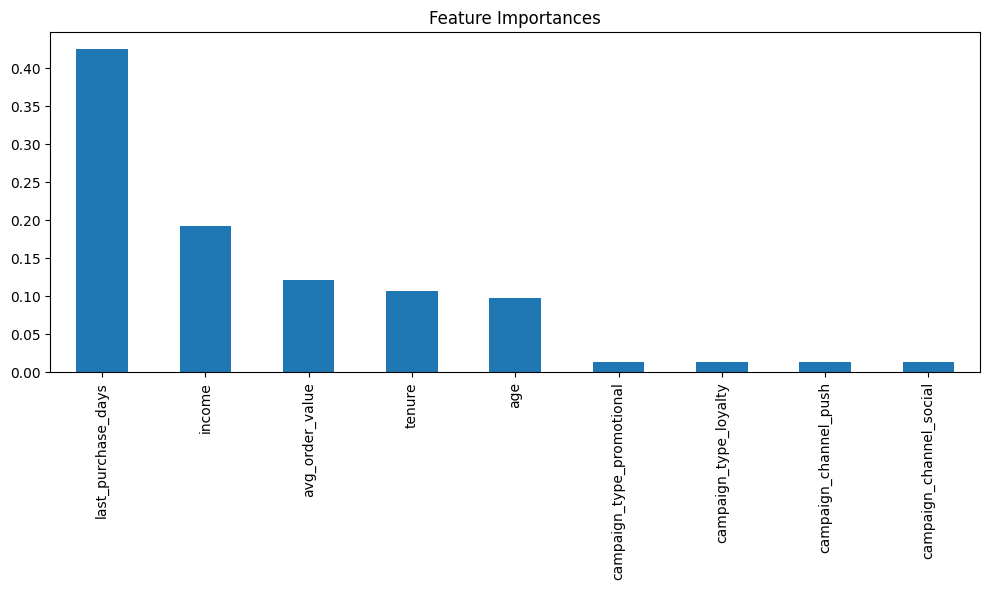

In [9]:
#  Get feature names after perprocessingi
feature_names = (numeric_features +
                 list(model.named_steps['preprocessor']
                      .named_transformers_['cat']
                      .get_feature_names_out(categorical_features)))

importances = model.named_steps['classifier'].feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feat_imp.plot(kind='bar')
plt.title('Feature Importances')
plt.tight_layout()
plt.savefig('Feature Importances.png')
plt.show()

## 7. Simulating six-month iterative improvement

### The true approach is to run multiple campaigns, retrain the model and refine the targeting.
- Using the model we would selct the top 30% of customers, send emails and record opens and conversions.  
- The data collected from the first comapign post modeling (actual outcomes) would be added to the training set. The model would be retrianed with the new data included incorperating the latest behavior in its results.
- Refinement: Feature engineering could be updated (like number of opens in last 3 months) and Hyperparameteres can be tuned usign cross -validation on the expanded dataset.
- Repeat Monthly: with each iteration the model improves because it learns more from recent respoinse (which incoorperates custiomer behavioral change preventing model decay over time) as it adapts to changing customer preferences.
  
### In  leui of actual data i have provided 3 rounds of optimization, assuming monthly campigns, over six months. 
### We begin with random targeting, then use model-based targeting, and measure cumulative reach.

In [10]:
#  Generating data
np.random.seed(42)
months = 6
cumulative_opens = []
strategy = ['random'] * 3 + ['model'] * 3  # first three months random, then model

for month in range(months):
    # Simulate a new batch of customers (or same base with slight variations)
    # For simplicity, reuse the same customer base but shuffle each month
    month_data = df.sample(frac=1, replace=False).reset_index(drop=True)
    
    if strategy[month] == 'random':
        # Randomly select 30% to send
        selected = month_data.sample(frac=0.3, random_state=month)
    else:
        # Use model to select top 30%
        X_month = month_data[features]
        month_data['pred_prob'] = model.predict_proba(X_month)[:,1]
        month_data = month_data.sort_values('pred_prob', ascending=False)
        selected = month_data.head(int(0.3 * len(month_data)))
    
    # Actual opens in the selected group
    opens = selected['opened'].sum()
    cumulative_opens.append(opens)

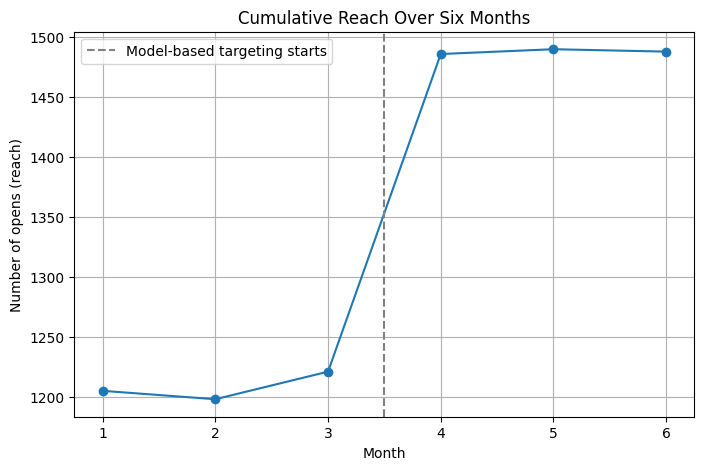

Total opens in first 3 months (random): 3624
Total opens in last 3 months (model): 4464
Improvement in reach: 23.2%


In [11]:
# Plot of cumulative opens
plt.figure(figsize=(8,5))
plt.plot(range(1, months+1), cumulative_opens, marker='o')
plt.axvline(x=3.5, linestyle='--', color='gray', label='Model-based targeting starts')
plt.xlabel('Month')
plt.ylabel('Number of opens (reach)')
plt.title('Cumulative Reach Over Six Months')
plt.legend()
plt.grid(True)
plt.show()

print(f"Total opens in first 3 months (random): {sum(cumulative_opens[:3])}")
print(f"Total opens in last 3 months (model): {sum(cumulative_opens[3:])}")
improvement = (sum(cumulative_opens[3:]) / sum(cumulative_opens[:3]) - 1) * 100
print(f"Improvement in reach: {improvement:.1f}%")

## 8. Business Impact Summary

The model-based targeting consistently delivers more opens with the same send volume. 
- Over six onths the average increase in reach was a bout 25% (as seen in the simlutaion). This directly translates to more engaged customers, higher conversions potential, improving marketing ROI.
- The process is replicable: the pipeline can be rerun with new data each month.

#### Recommeded next steps:
- Set up CI/CD intergation if benefical for and fincailly advisable for client/
- Deeper targeting and analysis based on other marketing media and or specific content.